# Data Exploaration Notebook 
We have three files `goodreads_books_young_adult.json`, `goodreads_reviews_young_adult.json`, and `goodreads_interactions_young_adult.json`. 
`goodreads_books_young_adult.json` gives us the metadata for each book, `goodreads_reviews_young_adult.json` gives us record of each review
`goodreads_interactions_young_adult.json` gives us a record of each user-book interaction.

In [ ]:
import os
from pathlib import Path
import duckdb
import polars as pl
import matplotlib.pyplot as plt

In [2]:
books_path = 'data/goodreads_books_young_adult.json'
reviews_path = 'data/goodreads_reviews_young_adult.json'
interactions_path = 'data/goodreads_interactions_young_adult.json'

In [6]:
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(80)

# One DuckDB connection
con = duckdb.connect()
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA threads=8")
con

# Analyze metadata file
Lets do a deep dive into `goodreads_books_young_adult.json`

In [8]:
# Lets start by creating a lazy polars reader
book_lazy_load = pl.scan_ndjson(books_path, infer_schema_length=2000) # only look at the first 2000 to get column type
schema = book_lazy_load.collect_schema() # get schema 

In [12]:
for name, dtype in schema.items():
    print(f'{name:35s}{dtype}')

isbn                               String
text_reviews_count                 String
series                             List(String)
country_code                       String
language_code                      String
popular_shelves                    List(Struct({'count': String, 'name': String}))
asin                               String
is_ebook                           String
average_rating                     String
kindle_asin                        String
similar_books                      List(String)
description                        String
format                             String
link                               String
authors                            List(Struct({'author_id': String, 'role': String}))
publisher                          String
num_pages                          String
publication_day                    String
isbn13                             String
publication_month                  String
edition_information                String
publication_year    

In [13]:
len(schema)

29

In [15]:
total_books = book_lazy_load.select(pl.len()).collect().item()
print(f"total of {total_books} books")

total of 93398 books


In [ ]:
key_columns = [
    'isbn', 'isbn13', 'title', 'description', 'language_code', 'average_rating',
    'publisher', 'publication_year', 'format', 'image_url', 'url',
] # these are key columns that have important info

In [23]:
key_columns = [c for c in key_columns if c in schema]


In [ ]:
missing = (
    book_lazy_load
    .select([
        ((pl.col(c).is_null()) | (pl.col(c).cast(pl.Utf8) == '')).mean().alias(c) # check if null or is blank
        for c in key_columns
    ])
    .collect()
    .transpose(include_header=True, header_name='field', column_names=['missing_frac'])
    .sort('missing_frac', descending=True)
)

In [25]:
missing

field,missing_frac
str,f64
"""isbn""",0.40518
"""language_code""",0.317266
"""isbn13""",0.287137
"""format""",0.19282
"""publication_year""",0.165989
"""description""",0.045911
"""title""",0.0
"""average_rating""",0.0
"""image_url""",0.0


In [28]:
books_ratings = (
    book_lazy_load
    .with_columns([
        pl.col('average_rating').cast(pl.Float64, strict=False),
        pl.col('ratings_count').cast(pl.Int64, strict=False),
        pl.col('text_reviews_count').cast(pl.Int64, strict=False),
    ])
    .select(['average_rating', 'ratings_count', 'text_reviews_count'])
    .collect()
)
len(books_ratings)

93398

In [29]:
books_ratings.describe()

statistic,average_rating,ratings_count,text_reviews_count
str,f64,f64,f64
"""count""",93398.0,93398.0,93398.0
"""null_count""",0.0,0.0,0.0
"""mean""",3.860503,1351.241536,101.913189
"""std""",0.345687,28857.589171,1159.965407
"""min""",0.0,0.0,0.0
"""25%""",3.66,15.0,3.0
"""50%""",3.87,48.0,9.0
"""75%""",4.09,184.0,29.0
"""max""",5.0,4.899965e6,142645.0


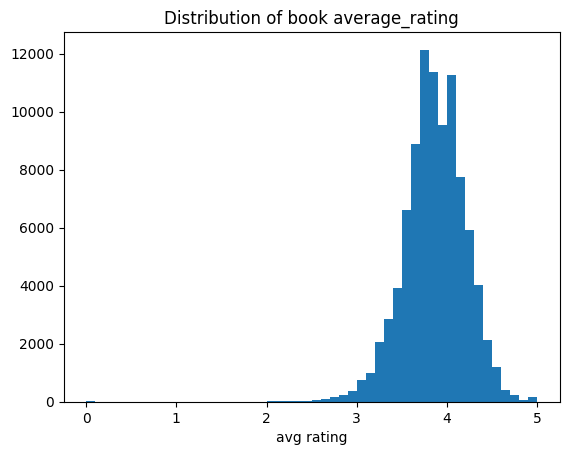

In [33]:
plt.hist(books_ratings['average_rating'].drop_nulls().to_numpy(), bins=50)
plt.title('Distribution of book average_rating')
plt.xlabel('avg rating')
plt.show()  # optional, to display the plot

In [34]:
# pblication year distribution
year_dist = (
    book_lazy_load
    .with_columns(pl.col('publication_year').cast(pl.Int32, strict=False))
    .filter(pl.col('publication_year').is_between(1900, 2025))
    .group_by('publication_year').agg(pl.len().alias('n'))
    .sort('publication_year')
    .collect()
)

In [35]:
year_dist

publication_year,n
i32,u32
1905,1
1909,1
1922,2
1924,2
1925,1
1927,1
1930,1
1933,1
1934,1


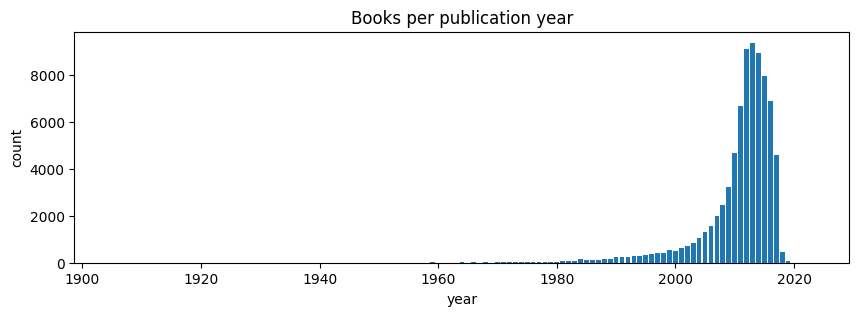

In [36]:
plt.figure(figsize=(10, 3))
plt.bar(year_dist['publication_year'].to_numpy(), year_dist['n'].to_numpy())
plt.title('Books per publication year')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

In [37]:
book_lazy_load.group_by('language_code').agg(pl.len().alias('n')).sort('n', descending=True).head(15).collect()

language_code,n
str,u32
"""eng""",35989
"""""",29632
"""en-US""",4996
"""en-GB""",2922
"""ger""",2798
"""spa""",2511
"""fre""",1788
"""ita""",1761
"""ind""",1623


In [38]:
book_lazy_load.group_by('format').agg(pl.len().alias('n')).sort('n', descending=True).head(15).collect()

format,n
str,u32
"""Paperback""",35946
"""""",18009
"""Hardcover""",15684
"""ebook""",9467
"""Kindle Edition""",7136
"""Audio CD""",2085
"""Audiobook""",1537
"""Mass Market Paperback""",1237
"""Audible Audio""",584


In [39]:
# Lets take a look at the popular shelves column which is 
# Top user-generated shelf tags sorted by count descending; used by Goodreads to infer genres

shelves = (
    book_lazy_load
    .select(pl.col('popular_shelves'))
    .explode('popular_shelves')
    .unnest('popular_shelves')
    .with_columns(pl.col('count').cast(pl.Int64, strict=False))
    .group_by('name')
    .agg([pl.len().alias('books_with_this_shelf'), pl.col('count').sum().alias('total_shelvings'),])
    .sort('total_shelvings', descending=True)
    .head(10)
    .collect()
)


In [40]:
shelves

name,books_with_this_shelf,total_shelvings
str,u32,i64
"""to-read""",92842,1040278717
"""favorites""",73297,63373578
"""young-adult""",90717,60695268
"""currently-reading""",84580,54490125
"""fantasy""",48224,33912560
"""ya""",81250,28215407
"""books-i-own""",70986,19022690
"""fiction""",75232,16787811
"""romance""",62400,16334945


# Analyze reviews file

In [43]:
import pyarrow

In [44]:
# we will be using duckdb streaming json reader 
con.execute(f"""
    CREATE OR REPLACE VIEW reviews AS
    SELECT * FROM read_json_auto('{reviews_path}', format='newline_delimited',
                                 sample_size=-1, ignore_errors=true)
""")
con.execute('DESCRIBE reviews').pl()

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""user_id""","""VARCHAR""","""YES""",null,null,null
"""book_id""","""VARCHAR""","""YES""",null,null,null
"""review_id""","""VARCHAR""","""YES""",null,null,null
"""rating""","""BIGINT""","""YES""",null,null,null
"""review_text""","""VARCHAR""","""YES""",null,null,null
"""date_added""","""VARCHAR""","""YES""",null,null,null
"""date_updated""","""VARCHAR""","""YES""",null,null,null
"""read_at""","""VARCHAR""","""YES""",null,null,null
"""started_at""","""VARCHAR""","""YES""",null,null,null


In [46]:
con.execute('SELECT COUNT(*) AS numberReviews FROM reviews ').pl()

numberReviews
i64
2389900


In [47]:
# get rating distribution 
rating_dist = con.execute("""
    SELECT rating, COUNT(*) AS n
    FROM reviews
    GROUP BY rating
    ORDER BY rating
""").pl()

In [48]:
rating_dist

rating,n
i64,i64
0,82177
1,70229
2,175108
3,475984
4,784116
5,802286


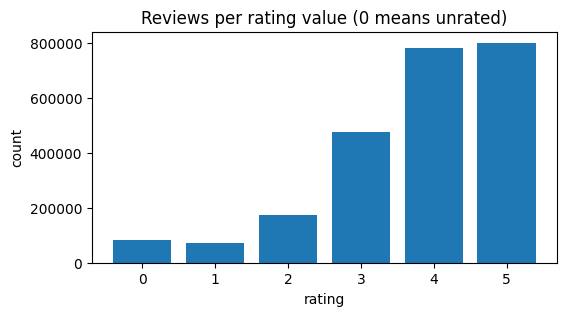

In [49]:
plt.figure(figsize=(6, 3))
plt.bar(rating_dist['rating'].to_numpy(), rating_dist['n'].to_numpy())
plt.title('Reviews per rating value (0 means unrated)')
plt.xlabel('rating')
plt.ylabel('count')
plt.show()

In [56]:
# lets now look at per user and per book activity, similar to chart given in the example notebooks 
reviews_each_userhas = con.execute(
    """
    SELECT numberOfReviews, COUNT(*) AS numberOfUsers
    FROM (SELECT user_id, COUNT(*) AS numberOfReviews FROM reviews GROUP BY user_id)
    GROUP BY numberOfReviews
    ORDER BY numberOfReviews
    """).pl()

In [57]:
reviews_each_userhas

numberOfReviews,numberOfUsers
i64,i64
1,68090
2,30047
3,18740
4,12788
5,9313
6,7384
7,5734
8,4723
9,3976


In [62]:
reviews_each_bookhas = con.execute(
    """
    SELECT numberOfReviews, COUNT(*) AS numberOfBooks
    FROM (SELECT book_id, COUNT(*) AS numberOfReviews FROM reviews GROUP BY book_id)
    GROUP BY numberOfReviews
    ORDER BY numberOfReviews
    """).pl()

In [63]:
reviews_each_bookhas

numberOfReviews,numberOfBooks
i64,i64
1,29149
2,13510
3,8110
4,5704
5,4225
6,3127
7,2659
8,2167
9,1856


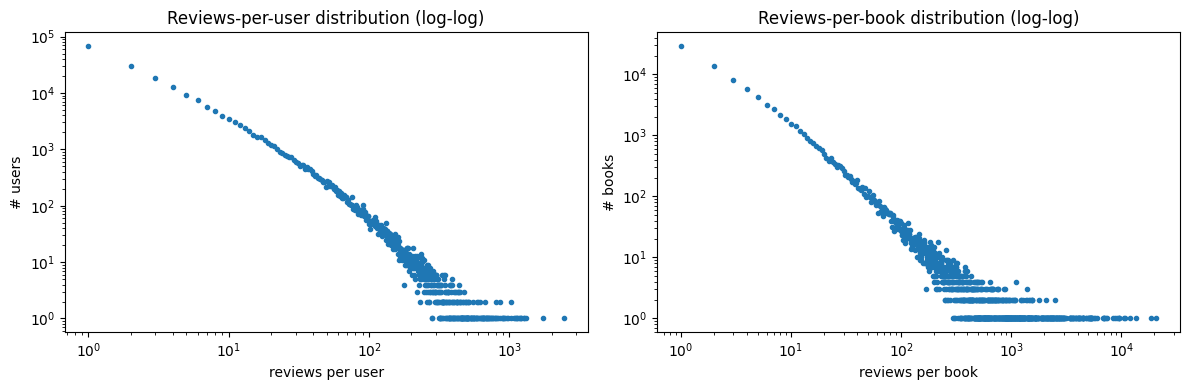

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(reviews_each_userhas['numberOfReviews'].to_numpy(), reviews_each_userhas['numberOfUsers'].to_numpy(), '.')
axes[0].set_title('Reviews-per-user distribution (log-log)')
axes[0].set_xlabel('reviews per user')
axes[0].set_ylabel('# users')
axes[1].loglog(reviews_each_bookhas['numberOfReviews'].to_numpy(), reviews_each_bookhas['numberOfBooks'].to_numpy(), '.')
axes[1].set_title('Reviews-per-book distribution (log-log)')
axes[1].set_xlabel('reviews per book')
axes[1].set_ylabel('# books')
plt.tight_layout()
plt.show()

In [65]:
# looking at text length and signal
text_stats = con.execute("""
    SELECT
        AVG(LENGTH(review_text))       AS avg_chars,
        MEDIAN(LENGTH(review_text))    AS median_chars,
        QUANTILE_CONT(LENGTH(review_text), 0.9)  AS p90_chars,
        QUANTILE_CONT(LENGTH(review_text), 0.99) AS p99_chars,
        AVG(n_votes)    AS avg_votes,
        AVG(n_comments) AS avg_comments
    FROM reviews
""").pl()


In [67]:
text_stats

avg_chars,median_chars,p90_chars,p99_chars,avg_votes,avg_comments
f64,f64,f64,f64,f64,f64
791.061662,351.0,2164.0,5118.0,1.269322,0.303311


In [70]:
# look at min and max date times!
dateRange = con.execute("""
    WITH parsed AS (
        SELECT strptime(date_added,'%a %b %d %H:%M:%S %z %Y') AS dt
        FROM reviews
        WHERE date_added <> ''
    )
    SELECT MIN(dt) AS first_review, MAX(dt) AS last_review, date_part('year', MAX(dt)) - date_part('year', MIN(dt)) AS span_years
    FROM parsed
""").pl()

In [71]:
dateRange

first_review,last_review,span_years
"datetime[μs, America/Los_Angeles]","datetime[μs, America/Los_Angeles]",i64
2001-09-12 00:00:00 PDT,2017-11-03 22:22:46 PDT,16


In [72]:
#check reviews per year 
reviews_per_year = con.execute(
    """
    SELECT date_part('year', strptime(date_added, '%a %b %d %H:%M:%S %z %Y')) AS yr, COUNT(*) AS n
    FROM reviews
    WHERE date_added <> ''
    GROUP BY yr ORDER BY yr
    """
    ).pl()

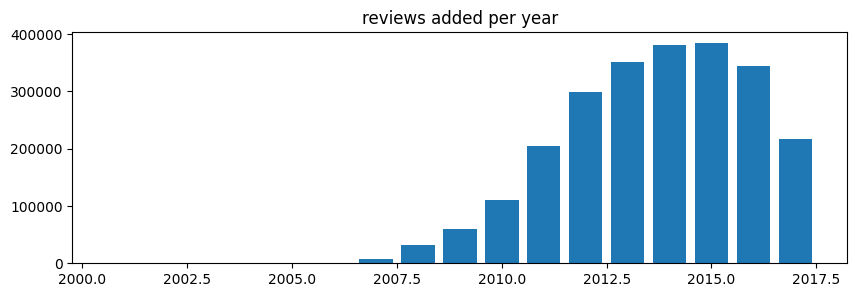

In [74]:
plt.figure(figsize=(10, 3))
plt.bar(reviews_per_year['yr'].to_numpy(), reviews_per_year['n'].to_numpy())
plt.title('reviews added per year')
plt.show()

# Analyze interactions


In [75]:
con.execute(f"""
    CREATE OR REPLACE VIEW interactions AS
    SELECT * FROM read_json_auto('{interactions_path}', format='newline_delimited',
                                 sample_size=-1, ignore_errors=true)
""")
con.execute('DESCRIBE interactions').pl()

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""user_id""","""VARCHAR""","""YES""",null,null,null
"""book_id""","""VARCHAR""","""YES""",null,null,null
"""review_id""","""VARCHAR""","""YES""",null,null,null
"""is_read""","""BOOLEAN""","""YES""",null,null,null
"""rating""","""BIGINT""","""YES""",null,null,null
"""review_text_incomplete""","""VARCHAR""","""YES""",null,null,null
"""date_added""","""VARCHAR""","""YES""",null,null,null
"""date_updated""","""VARCHAR""","""YES""",null,null,null
"""read_at""","""VARCHAR""","""YES""",null,null,null


In [76]:
n_interactions = con.execute('SELECT COUNT(*) FROM interactions').fetchone()

In [77]:
n_interactions

(34919254,)

In [91]:
PARQUET = 'data/interactions_youngAdult.parquet'
con.execute(f"""
        COPY (
            SELECT user_id, book_id, is_read::BOOLEAN AS is_read, rating::TINYINT  AS rating, date_added, date_updated
            FROM interactions
        ) TO '{PARQUET}' (FORMAT 'parquet', COMPRESSION 'zstd');
    """)

con.execute(f"CREATE OR REPLACE VIEW ix AS SELECT * FROM read_parquet('{PARQUET}')")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [92]:
con.execute("""
    SELECT is_read,
           rating,
           COUNT(*) AS n
    FROM ix
    GROUP BY is_read, rating
    ORDER BY is_read, rating
""").pl()

is_read,rating,n
bool,i8,i64
false,0,19196505
true,0,990841
true,1,361459
true,2,974247
true,3,3243461
true,4,5058507
true,5,5094234


In [93]:
dataCounts = con.execute("""
    SELECT COUNT(DISTINCT user_id) AS n_users,
           COUNT(DISTINCT book_id) AS n_books,
           COUNT(*) AS n_interactions
    FROM ix
""").pl()
dataCounts

n_users,n_books,n_interactions
i64,i64,i64
644686,93398,34919254


In [98]:
n_users = dataCounts['n_users'][0]
n_books = dataCounts['n_books'][0]
n_interactions = dataCounts['n_interactions'][0]
density = n_interactions / (n_users * n_books)
print(f'Users: {n_users}')
print(f'Books: {n_books}')
print(f'Interactions: {n_interactions}')
print(f'Density of user x book matrix: {density}')
print(f'{density*100}% of cells are filled')

Users: 644686
Books: 93398
Interactions: 34919254
Density of user x book matrix: 0.0005799347616546222
0.05799347616546222% of cells are filled


In [100]:
user_activity = con.execute("""
    SELECT COUNT(*) AS n_books_each_user
    FROM ix
    GROUP BY user_id
""").pl()

book_activity = con.execute("""
    SELECT COUNT(*) AS n_users_each_book
    FROM ix
    GROUP BY book_id
""").pl()

In [101]:
user_activity

n_books_each_user
i64
5
4
13
61
26
16
15
26
7


In [102]:
user_activity.describe()

statistic,n_books_each_user
str,f64
"""count""",644686.0
"""null_count""",0.0
"""mean""",54.164747
"""std""",147.262402
"""min""",1.0
"""25%""",3.0
"""50%""",13.0
"""75%""",47.0
"""max""",11031.0


In [103]:
book_activity.describe()

statistic,n_users_each_book
str,f64
"""count""",93398.0
"""null_count""",0.0
"""mean""",373.875822
"""std""",3109.196432
"""min""",1.0
"""25%""",8.0
"""50%""",26.0
"""75%""",107.0
"""max""",313343.0


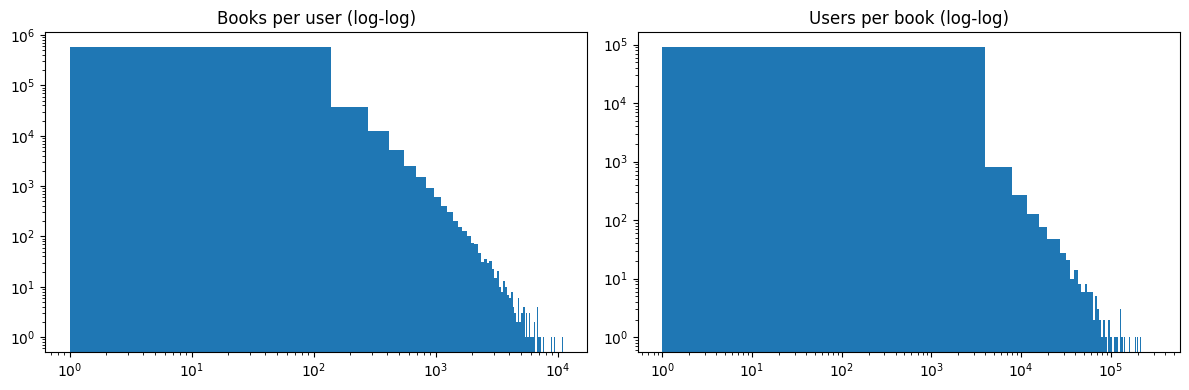

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_activity['n_books_each_user'].to_numpy(), bins=80, log=True)
axes[0].set_xscale('log')
axes[0].set_title('Books per user (log-log)')
axes[1].hist(book_activity['n_users_each_book'].to_numpy(), bins=80, log=True)
axes[1].set_xscale('log')
axes[1].set_title('Users per book (log-log)')
plt.tight_layout(); plt.show()